# ML1 — Introduction to Machine Learning
**Author:** Zef (Ahsan Mustafa) 
**Dataset:** Two Sigma Connect: Rental Listing Inquiries (renthop.com)

---
## Section 1: Intro — ML Concepts

### 1.1 — Five Real-World Examples of ML

For each example, describe the application and the benefit of using ML over traditional methods.

1. **Cancer Cell Detection** — Benefit: Conventional methods are painstaking. By using ML, we can detect anomolies and detect the potential patients that may develop cancer cells or when cancer cells are still in early stages based on hisotrical data. This method allows to move forward proactively, while there is still time.
2. **Road Defect Detection** — Benefit: Using ML, we can classify different road defects quickly just looking from UAV photos, and create reporting and managing road safety easy.
3. **Event Planning** — Benefit: Managing certain social events that are open to public without requiring any pre-registration can benefit form ML, where we can predict how many people might attend an event based on historical data or data of competitors in a space.
4. **Banking Fraud Detection** — Benefit: Realtime anomoly detection in banking apps based on historical usage patterns to restrict usage for a certain time to make sure it is not a fraud. 
5. **Manufactoring** — Benefit: Analyzing sensor data to anticipate equipment failure before it happens, reducing downtime.

### 1.2 — Classification of Tasks from the Table

For each task, classify it as supervised/unsupervised, and (if supervised) regression or classification.

| # | Task | Type | Reasoning |
|---|------|------|------------|
| 1 | Predict house price | Supervised — Regression | The target (price) is a continuous value. Performance is measured by how close the prediction is. |
| 2 | Predict whether a client returns a loan | Supervised — Binary Classification | The output is yes/no. Performance is whether the prediction is correct. |
| 3 | Predict when a patient needs to take medicine | Supervised — Regression | "When" implies a continuous time value as output. Could also be framed as classification (e.g. needs medicine in next 6 hours: yes/no). |
| 4 | Choose what medicine a patient should take | Supervised — Multiclass Classification | Output is one of several discrete medicine options. Performance is whether the medicine helps. |
| 5 | Choose segment of clients for promo communication | Supervised - Binary Classification | Output is wether a client belongs to the segment that the promo will be communicated to. Historical data is avaialble. |
| 6 | Recognition of defective products from photo scans | Supervised — Binary Classification | Output is defective or non-defective. Labeled training data (photos of both) is available. |
| 7 | Decide how to place products on a shelf | Supervised — Regression (or Reinforcement Learning) | Performance measure (sales, profit) is continuous. Historical placement data is available. |
| 8 | Search sites for input text query | Supervised — Learning to Rank | Goal is to rank results by relevance. Not pure regression — output is an ordered list, not a single number. |
| 9 | Split customers into segments | Unsupervised — Clustering | No labeled output. Goal is to discover natural groupings in customer behaviour. |
| 10 | Detect anomaly in site traffic | Unsupervised — Anomaly Detection | No labeled anomalies. Goal is to identify unusual patterns without prior examples. |

### 1.3 — Multiclass vs Multilabel Classification

In multiclass, we have one distinct output classification for each input. For example, we have images, we label them as dog, cat or etc. One image can not be both cat and dog.

In multilabel, one input can have multiple outputs. For example, we read an article and assign different labels at the end. One article can be related to finance, government, and crypto at the same time. This kind of classification can be difficult, since we often don't know what "right" means here.

### 1.4 — Regression vs Classification: The House Price Problem

The house price problem is essentially a regression problem, but yes, it can be reduce to a classification problem by creating classes of different ranges that a particular house might lie in based on the characteristics such as the location, number of bedrooms, bathrooms etc.

By turning it into a classification problem, we can often lose the nuance of our results. Let's say our prediction for a house price is 305,000. If it goes in a bucket range of 300,000-400,000, that is too wide. If the bucket is 300,000 - 310,000, that is better. But in regression, it will be exactly 304,000, and every dollar counts.

---
## Section 2: Introduction to Data Analysis

In [1]:
!pip install lightgbm

In [2]:
# 2.1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import scipy
import statsmodels.api as sm
import lightgbm as lgb

%matplotlib inline

In [3]:
# 2.2 — Load the data
df = pd.read_json('../datasets/train.json')
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [4]:
# 2.3 — Shape of the data
df.shape

(49352, 15)

In [5]:
# 2.4 — Column names and target identification
print(df.columns)
print("Price is the clear target")

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')
Price is the clear target


In [6]:
# 2.5 — Quick analysis: info(), describe(), corr()
print(df.info())
print(df.describe())
print(df.corr())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB
None
         bathrooms      bedrooms      lat

**Your observations from info(), describe(), corr():**

- `info()`: I see that we have a total of 15 columns, and each column has 49352 non-null values.
- `describe()`: Looking at our price (target) coumn, there is big gap between mean 3,830 and max 4,490,000. This tells me that most prices are on the lower end, but the data contains extreme outliers.
- `corr()`: The strongest co-relation I see is between longitude and latitude. However, when I compare their corelation with the corelation to price, it seems small.
- Any null/empty columns? No.

In [7]:
# 2.6 — Create a subset dataframe with only the 4 relevant columns
# Columns: 'bathrooms', 'bedrooms', 'interest_level', 'price'
df_sub = df[['bathrooms', 'bedrooms', 'interest_level', 'price']]
df_sub.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


---
## Section 3: Statistical Data Analysis

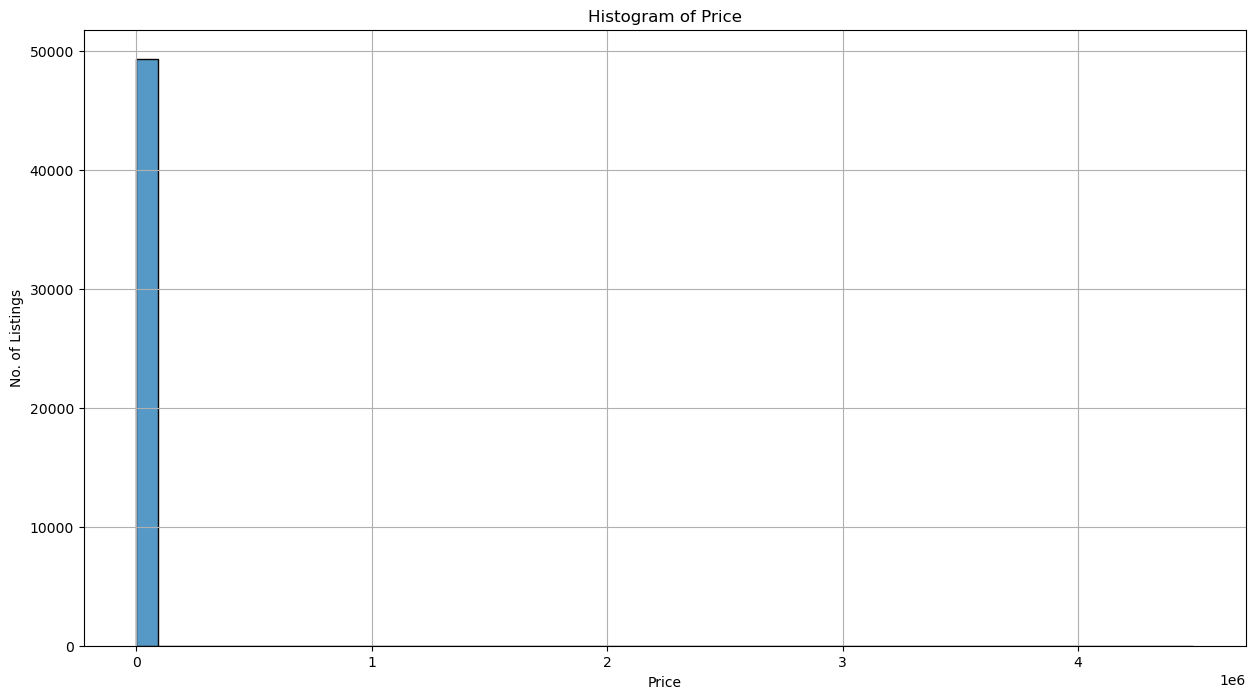

In [8]:
# 3.1 — Target analysis: histogram of 'price'
plt.figure(figsize=(15, 8))
sns.histplot(data=df_sub, x='price', bins=50)
plt.title('Histogram of Price')
plt.ylabel('No. of Listings')
plt.xlabel('Price')
plt.grid()
plt.show()

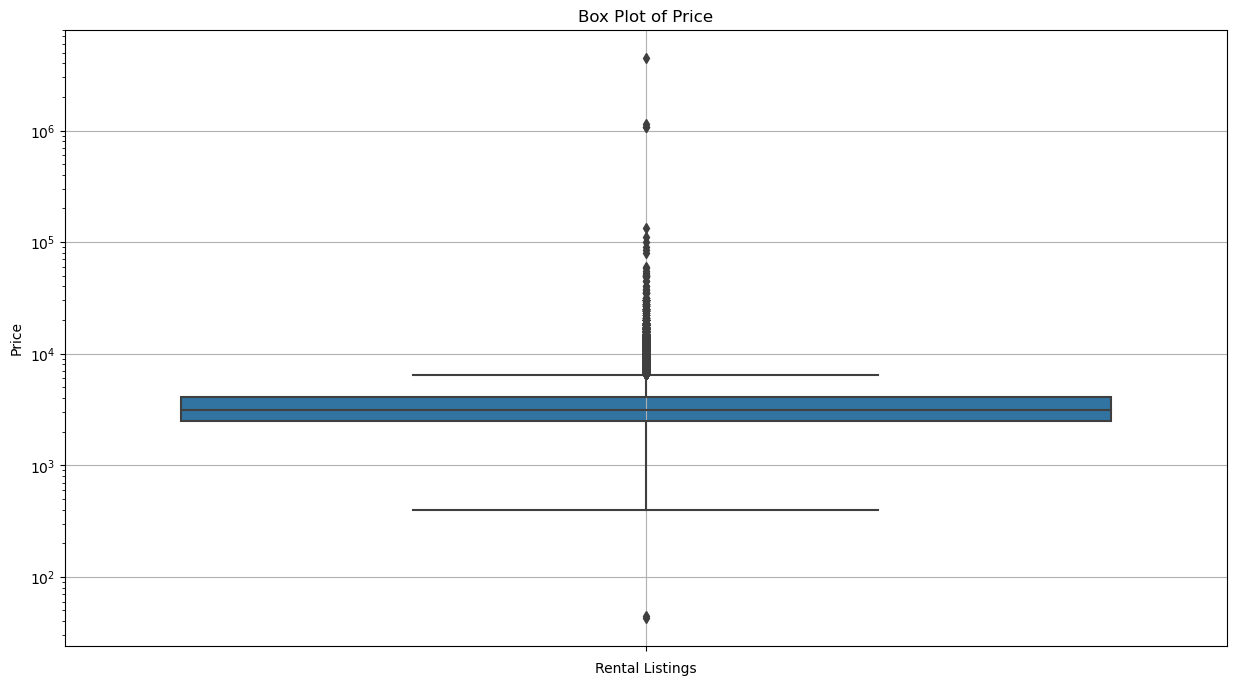

In [9]:
# 3.2 — Boxplot of 'price'
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_sub, y='price')
plt.title('Box Plot of Price')
plt.ylabel('Price')
plt.xlabel('Rental Listings')
plt.grid()
plt.yscale('log')
plt.show()

In [10]:
# 3.3 — Drop rows outside 1st and 99th percentiles of 'price'
first, ninety_nine = df_sub['price'].quantile([0.01, 0.99])
print(first, ninety_nine)

df_sub = df_sub[(df_sub['price'] >= first) & (df_sub['price'] <= ninety_nine)]

1475.0 13000.0


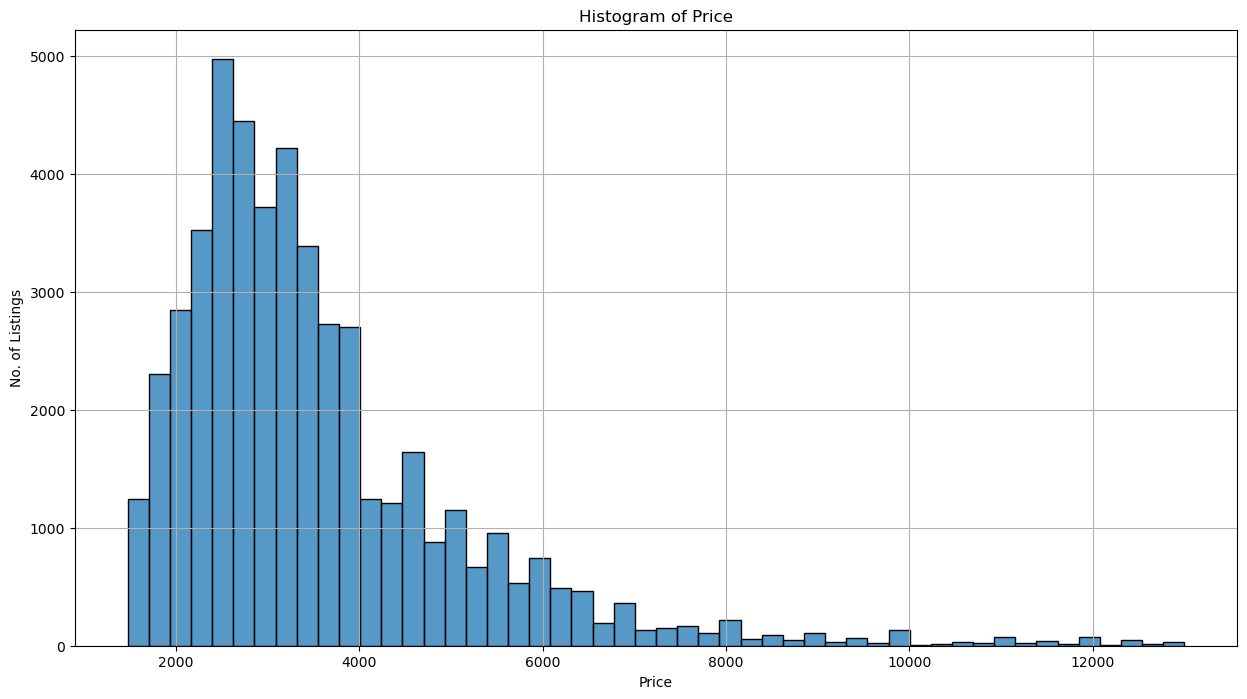

In [11]:
# 3.4 — Plot histogram of 'price' after removing outliers
plt.figure(figsize=(15, 8))
sns.histplot(data=df_sub, x='price', bins=50)
plt.title('Histogram of Price')
plt.ylabel('No. of Listings')
plt.xlabel('Price')
plt.grid()
plt.show()

In [12]:
# 3.5 — interest_level: type, value counts, encode
print("Data type of interest_level: ",df_sub['interest_level'].dtype)
print("Value Counts:\n", df_sub['interest_level'].value_counts())
df_sub['interest_level'] = df_sub['interest_level'].map({'low': 0, 'medium': 1, 'high': 2})

Data type of interest_level:  object
Value Counts:
 low       33697
medium    11116
high       3566
Name: interest_level, dtype: int64


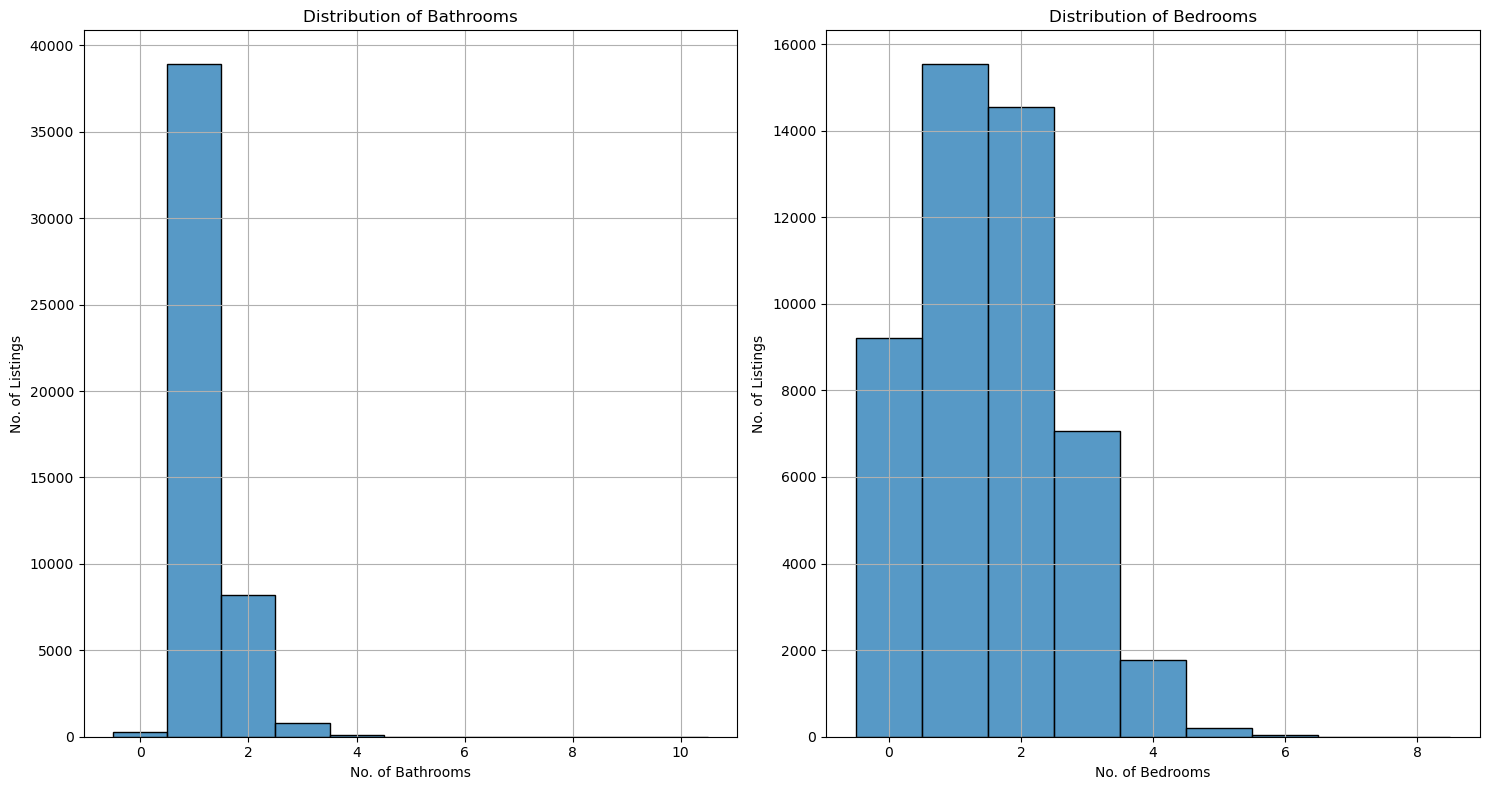

In [13]:
# 3.6 — Histograms for 'bathrooms' and 'bedrooms'
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
sns.histplot(data=df_sub, x='bathrooms', discrete=True)
plt.title('Distribution of Bathrooms')
plt.ylabel('No. of Listings')
plt.xlabel('No. of Bathrooms')
plt.grid()
plt.subplot(1, 2, 2)
sns.histplot(data=df_sub, x='bedrooms', discrete=True)
plt.title('Distribution of Bedrooms')
plt.ylabel('No. of Listings')
plt.xlabel('No. of Bedrooms')
plt.grid()
plt.tight_layout()
plt.show()

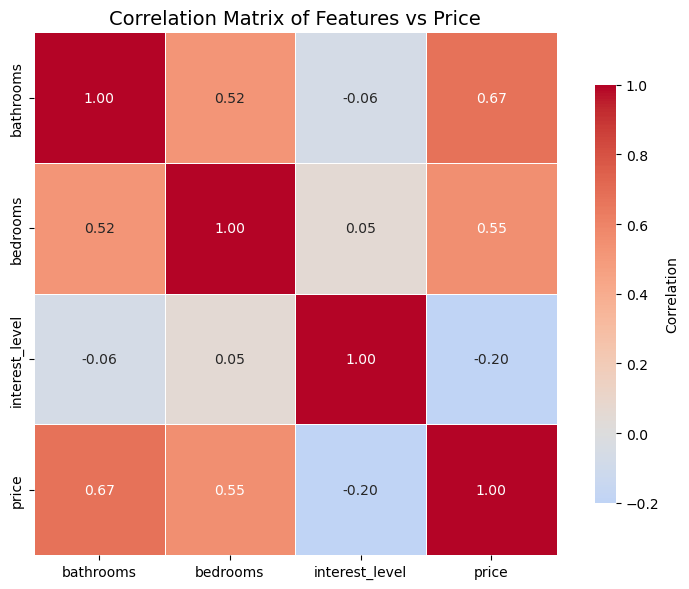

In [14]:
# 3.7 — Correlation matrix + heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_sub.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)
plt.title("Correlation Matrix of Features vs Price", fontsize=14)
plt.tight_layout()
plt.show()

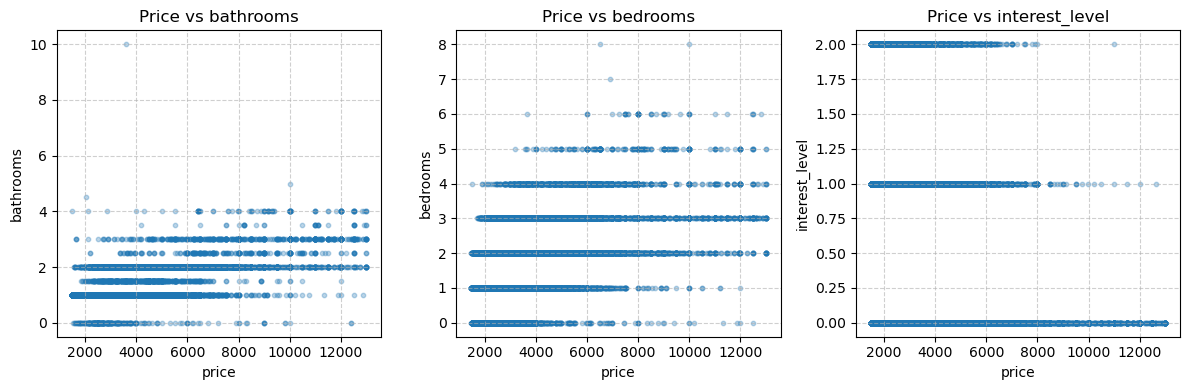

In [15]:
# 3.8 — Scatterplots: price (x) vs each feature (y)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
features = ['bathrooms', 'bedrooms', 'interest_level']
for ax, col in zip(axes, features):
    ax.scatter(df_sub['price'], df_sub[col], alpha=0.3, s=10)
    ax.set_xlabel('price')
    ax.set_ylabel(col)
    ax.set_title(f'Price vs {col}')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

---
## Section 4: Creating Features

In [16]:
# 4.1 — Create squared features and plot updated correlation matrix
df_sub['bathrooms_squared'] = np.square(df_sub['bathrooms'])
df_sub['bedrooms_squared'] = np.square(df_sub['bedrooms'])
df_sub['interest_level_squared'] = np.square(df_sub['interest_level'])

In [17]:
print(df_sub.corr())

                        bathrooms  bedrooms  interest_level     price  \
bathrooms                1.000000  0.517574       -0.063635  0.671943   
bedrooms                 0.517574  1.000000        0.050654  0.545948   
interest_level          -0.063635  0.050654        1.000000 -0.200111   
price                    0.671943  0.545948       -0.200111  1.000000   
bathrooms_squared        0.956023  0.478817       -0.068558  0.648486   
bedrooms_squared         0.548760  0.928277        0.046340  0.543406   
interest_level_squared  -0.059410  0.039511        0.944013 -0.182672   

                        bathrooms_squared  bedrooms_squared  \
bathrooms                        0.956023          0.548760   
bedrooms                         0.478817          0.928277   
interest_level                  -0.068558          0.046340   
price                            0.648486          0.543406   
bathrooms_squared                1.000000          0.522227   
bedrooms_squared                 0.52

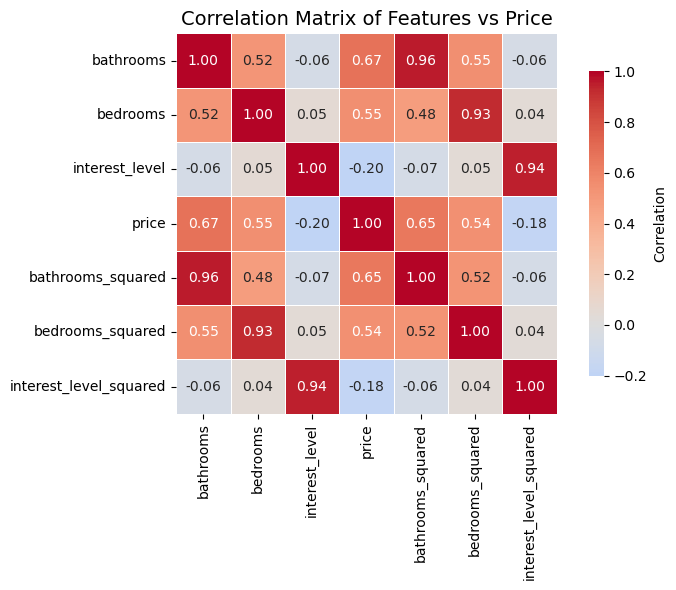

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_sub.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)
plt.title("Correlation Matrix of Features vs Price", fontsize=14)
plt.tight_layout()
plt.show()

Q: Are the new features more correlated with the target than the basic features?
Ans: No

In [19]:
# 4.2 — Load pre-split train/test data
train = pd.read_json('../datasets/train.json')
test  = pd.read_json('../datasets/test.json')


q_low, q_high = train['price'].quantile([0.01, 0.99])
train = train[(train['price'] >= q_low) & (train['price'] <= q_high)]

# filter test  
test = test[(test['price'] >= q_low) & (test['price'] <= q_high)]

X_train = train[['bathrooms', 'bedrooms']]
y_train = train['price']
X_test  = test[['bathrooms', 'bedrooms']]
y_test  = test['price']

In [20]:
# 4.3 — Initialize PolynomialFeatures with degree=10
poly = PolynomialFeatures(degree=10)

In [21]:
# 4.4 — Fit on train, transform both train and test
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

---
## Section 5: Model Training & Evaluation

In [22]:
# 5.1 — Create result tables
result_MAE  = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [23]:
# 5.2 — Linear Regression
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred_train = lr.predict(X_train_poly)
y_pred_test  = lr.predict(X_test_poly)


# Calculate MAE for train and test
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test, y_pred_test)

# Calculate RMSE for train and test
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Store results in the tables
result_MAE  = pd.concat([result_MAE,  pd.DataFrame([{'model': 'linear_regression', 'train': mae_train,  'test': mae_test}])],  ignore_index=True)
result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{'model': 'linear_regression', 'train': rmse_train, 'test': rmse_test}])], ignore_index=True)

In [24]:
# 5.3 — Decision Tree
dt = DecisionTreeRegressor(random_state=21)
dt.fit(X_train, y_train)
y_pred_train = dt.predict(X_train)
y_pred_test  = dt.predict(X_test)

# Calculate MAE for train and test
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test, y_pred_test)

# Calculate RMSE for train and test
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Store results in the tables
result_MAE  = pd.concat([result_MAE,  pd.DataFrame([{'model': 'decision_tree', 'train': mae_train,  'test': mae_test}])],  ignore_index=True)
result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{'model': 'decision_tree', 'train': rmse_train, 'test': rmse_test}])], ignore_index=True)

In [25]:
# 5.4 — Naive Models (mean baseline)
mean = y_train.mean()
y_naive_mean_train = np.full(len(y_train), mean)
y_naive_mean_test  = np.full(len(y_test), mean)


# Calculate MAE for train and test
mae_train = mean_absolute_error(y_train, y_naive_mean_train)
mae_test  = mean_absolute_error(y_test, y_naive_mean_test)

# Calculate RMSE for train and test
rmse_train = np.sqrt(mean_squared_error(y_train, y_naive_mean_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_naive_mean_test))

# Store results in the tables
result_MAE  = pd.concat([result_MAE,  pd.DataFrame([{'model': 'mean', 'train': mae_train,  'test': mae_test}])],  ignore_index=True)
result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{'model': 'mean', 'train': rmse_train, 'test': rmse_test}])], ignore_index=True)

In [26]:
# 5.4 — Naive Models (median baseline)
median = y_train.median()
y_naive_median_train = np.full(len(y_train), median)
y_naive_median_test  = np.full(len(y_test), median)


# Calculate MAE for train and test
mae_train = mean_absolute_error(y_train, y_naive_median_train)
mae_test  = mean_absolute_error(y_test, y_naive_median_test)

# Calculate RMSE for train and test
rmse_train = np.sqrt(mean_squared_error(y_train, y_naive_median_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_naive_median_test))

# Store results in the tables
result_MAE  = pd.concat([result_MAE,  pd.DataFrame([{'model': 'median', 'train': mae_train,  'test': mae_test}])],  ignore_index=True)
result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{'model': 'median', 'train': rmse_train, 'test': rmse_test}])], ignore_index=True)

In [27]:
# 5.5 — Print final result tables and identify the best model
print('=== MAE Results ===')
print(result_MAE)
print('\n=== RMSE Results ===')
print(result_RMSE)

=== MAE Results ===
               model        train          test
0  linear_regression   756.044737  3.765010e+16
1      decision_tree   756.044735  7.596148e+02
2               mean  1139.192515  1.137832e+03
3             median  1086.210505  1.084588e+03

=== RMSE Results ===
               model        train          test
0  linear_regression  1077.483596  1.019025e+19
1      decision_tree  1077.483596  1.081242e+03
2               mean  1597.646655  1.590391e+03
3             median  1644.236439  1.635396e+03


The winner is the Decision Tree — test MAE of about 756, meaning on average it predicts rental price within $756. Its train and test scores are almost identical (756 vs 759), which means it generalised well.